In [1]:
from final_data import titanic_data, titanic_test_data, titanic_gender_submission
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

In [2]:
data = titanic_data()
X = data[['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked',
       'Gender', 'FareGroup', 'AgeGroup', 'FamilySize', 'FarePerPerson', 'IsAlone']]
y = data['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=19)

In [3]:
print(X_train.dtypes)

Pclass              int64
Age               float64
SibSp               int64
Parch               int64
Fare              float64
Embarked           object
Gender             object
FareGroup        category
AgeGroup         category
FamilySize          int64
FarePerPerson     float64
IsAlone             int64
dtype: object


In [4]:
numeric_features = [
    'Pclass',
    'Age',
    'SibSp',
    'Parch',
    'Fare',
    'FamilySize',
    'FarePerPerson',
    'IsAlone'
]

categorical_features = [
    'Embarked',
    'Gender',
    'FareGroup',
    'AgeGroup'
]

In [5]:
preprocessor = ColumnTransformer([
    ('numeric', StandardScaler(), numeric_features),
    ('categorical', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

pipe_line = Pipeline([
    ('preprocessor', preprocessor),
    ('adaboost', AdaBoostClassifier())
], verbose=True)

pipe_line.fit(X_train, y_train)

[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.2s


,steps,"[('preprocessor', ...), ('adaboost', ...)]"
,transform_input,None
,memory,None
,verbose,True
,transformers,"[('numeric', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [6]:
param_grid = {
    'adaboost__algorithm': ['SAMME'],
    'adaboost__estimator': [
        DecisionTreeClassifier(max_depth=1, random_state=42),
        DecisionTreeClassifier(max_depth=2, random_state=42),
        DecisionTreeClassifier(max_depth=3, random_state=42)
        ],
    'adaboost__n_estimators': [30, 50, 70, 90],
    'adaboost__learning_rate': [1, 2, 3, 4, 6],
}

In [7]:
grid = GridSearchCV(estimator=pipe_line, param_grid=param_grid, cv=5, verbose=1, scoring='accuracy')
grid.fit(X_train, y_train)

Fitting 5 folds for each of 60 candidates, totalling 300 fits
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.2s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.2s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.2s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.2s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.2s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.3s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.2s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.2s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.2s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.2s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.2s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.2s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.2s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.2s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.2s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.2s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.2s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.2s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.2s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.2s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.2s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.2s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.2s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.2s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.2s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.2s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.2s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.2s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.3s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.2s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.2s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.2s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.2s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.2s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.2s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.2s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.2s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.2s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.2s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.2s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.2s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.2s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.2s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.2s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.2s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.2s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.2s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.2s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.2s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.2s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.2s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.2s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.2s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.2s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.3s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.2s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.2s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.2s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.2s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.2s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.2s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.2s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.2s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.2s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.2s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.2s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.2s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.2s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.2s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.2s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.2s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.2s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.2s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.2s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.2s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.2s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.2s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.2s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.2s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.2s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.2s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.2s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.2s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.2s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.2s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.2s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.2s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.2s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.2s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.2s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.2s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.2s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.2s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.2s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.2s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.2s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.2s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.2s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.2s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.2s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.2s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.2s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.2s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s


f:\download\python 3.10.11\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


[Pipeline] .......... (step 2 of 2) Processing adaboost, total=   0.2s


,estimator,Pipeline(step... verbose=True)
,param_grid,"{'adaboost__algorithm': ['SAMME'], 'adaboost__estimator': [DecisionTreeC...ndom_state=42), DecisionTreeC...ndom_state=42), ...], 'adaboost__learning_rate': [1, 2, ...], 'adaboost__n_estimators': [30, 50, ...]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('numeric', ...), ('categorical', ...)]"


In [8]:
grid.best_params_

{'adaboost__algorithm': 'SAMME',
 'adaboost__estimator': DecisionTreeClassifier(max_depth=3, random_state=42),
 'adaboost__learning_rate': 1,
 'adaboost__n_estimators': 90}

In [9]:
grid.best_score_

np.float64(0.8118067978533094)

In [10]:
test_data = titanic_test_data()
gender_submission_data = titanic_gender_submission()
X_test = test_data[['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked',
       'Gender', 'FareGroup', 'AgeGroup', 'FamilySize', 'FarePerPerson', 'IsAlone']]
y_test = gender_submission_data['Survived']

In [11]:
test_accuracy = grid.score(X_test, y_test)
test_accuracy

0.8755980861244019

In [12]:
pred = grid.predict(X_test)

print(confusion_matrix(y_test, pred))
print(classification_report(y_test, pred))

[[244  22]
 [ 30 122]]
              precision    recall  f1-score   support

           0       0.89      0.92      0.90       266
           1       0.85      0.80      0.82       152

    accuracy                           0.88       418
   macro avg       0.87      0.86      0.86       418
weighted avg       0.87      0.88      0.87       418



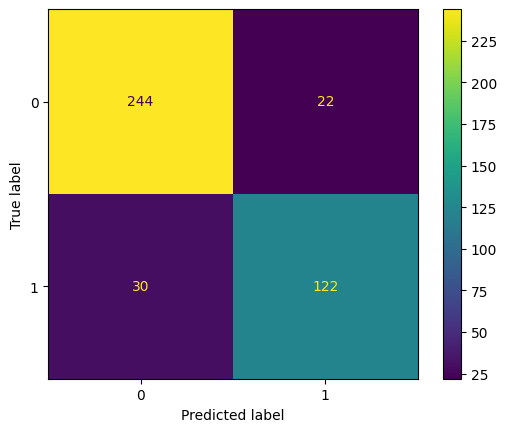

In [13]:
ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, pred), display_labels=grid.classes_).plot()